<a href="https://colab.research.google.com/github/ankit-kr6/LEARNING-ML/blob/main/video_24.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [30]:
!kaggle datasets download -d d4rklucif3r/social-network-ads

Dataset URL: https://www.kaggle.com/datasets/d4rklucif3r/social-network-ads
License(s): Community Data License Agreement - Permissive - Version 1.0
social-network-ads.zip: Skipping, found more recently modified local copy (use --force to force download)


In [31]:
import zipfile
with zipfile.ZipFile('social-network-ads.zip', 'r') as zip_ref:
    zip_ref.extractall('/content')

In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [33]:
df = pd.read_csv('Social_Network_Ads.csv')

In [34]:
df.sample(5)

,Age,EstimatedSalary,Purchased
372,39,73000,0
92,26,15000,0
316,54,104000,1
67,23,82000,0
330,38,51000,0


In [35]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df.drop("Purchased", axis=1), df['Purchased'], test_size=0.3, random_state=0)
X_train.shape, X_test.shape

((280, 2), (120, 2))

In [36]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train_scaled = sc.fit_transform(X_train)
X_test_scaled = sc.transform(X_test)

In [37]:
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

In [40]:
np.round(X_train_scaled.describe(), 1)

,Age,EstimatedSalary
count,280.0,280.0
mean,0.0,0.0
std,1.0,1.0
min,-1.9,-1.6
25%,-0.8,-0.8
50%,-0.1,0.0
75%,0.8,0.5
max,2.2,2.3


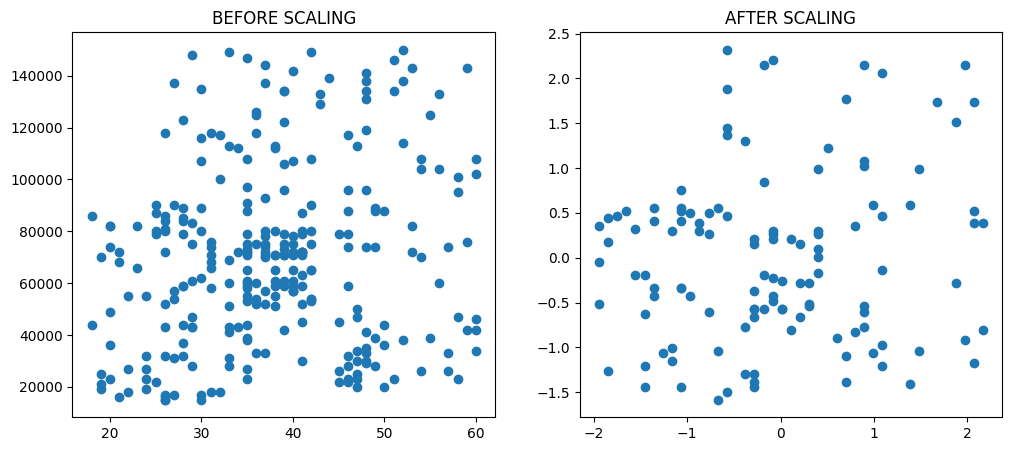

In [44]:
fig,(ax1,ax2) = plt.subplots(ncols=2, figsize=(12, 5))
ax1.scatter(X_train['Age'], X_train['EstimatedSalary'])
ax1.set_title('BEFORE SCALING')
ax2.scatter(X_test_scaled['Age'], X_test_scaled['EstimatedSalary'])
ax2.set_title('AFTER SCALING')
plt.show()

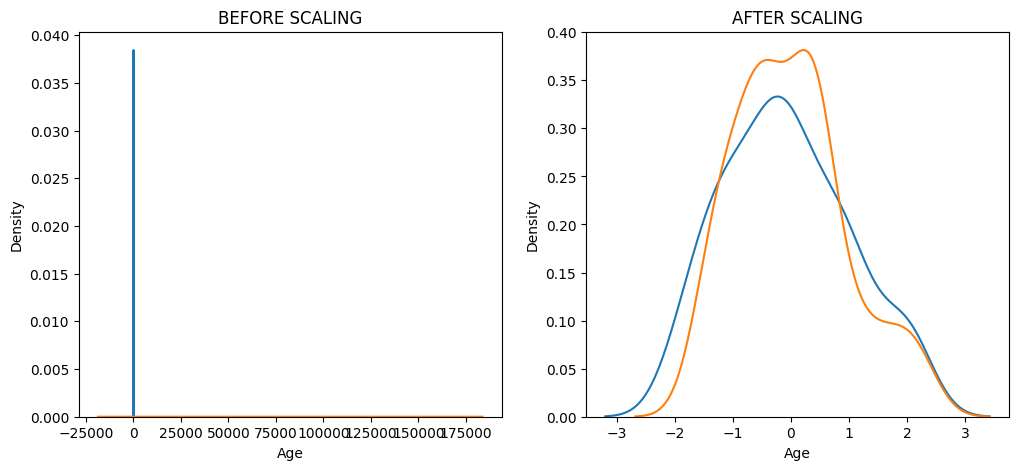

In [45]:
fig,(ax1,ax2) = plt.subplots(ncols=2, figsize=(12, 5))
ax1.set_title('BEFORE SCALING')
sns.kdeplot(X_train['Age'], ax=ax1)
sns.kdeplot(X_train['EstimatedSalary'], ax=ax1)
ax2.set_title('AFTER SCALING')
sns.kdeplot(X_test_scaled['Age'], ax=ax2)
sns.kdeplot(X_test_scaled['EstimatedSalary'], ax=ax2)
plt.show()

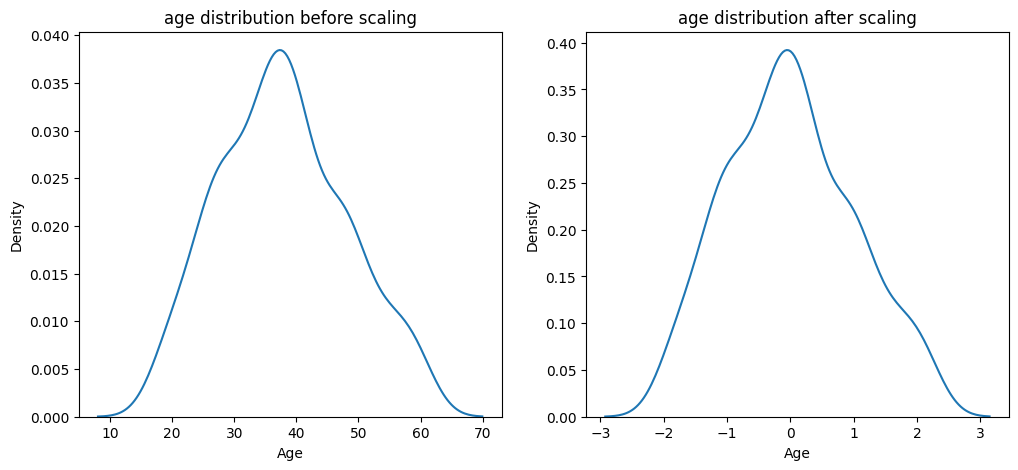

In [47]:
fig,(ax1,ax2) = plt.subplots(ncols=2, figsize=(12, 5))
ax1.set_title("age distribution before scaling")
sns.kdeplot(X_train['Age'], ax=ax1)
ax2.set_title("age distribution after scaling")
sns.kdeplot(X_train_scaled['Age'], ax=ax2)
plt.show()

In [48]:
from sklearn.linear_model import LogisticRegression
log_reg = LogisticRegression()
log_reg_scaled = LogisticRegression()
log_reg.fit(X_train, y_train)
log_reg_scaled.fit(X_train_scaled, y_train)

LogisticRegression()

In [49]:
y_pred = log_reg.predict(X_test)
y_pred_scaled = log_reg_scaled.predict(X_test_scaled)

In [52]:
from sklearn.metrics import accuracy_score
print(accuracy_score(y_test, y_pred))
print(accuracy_score(y_test, y_pred_scaled))

0.875
0.8666666666666667
